# Phase 5: Expirementation with Kronecker Sequences

First we import

In [15]:
import math
import itertools
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import time
import sympy as sp
from sympy.polys.matrices import DomainMatrix


Then we create a more efficeint algorithm for rho computation, for kronecker sequences

In [2]:
# ============================================================
# Helpers
# ============================================================

def centered_mod(x, N):
    """
    Return the centered representative of x mod N in (-N/2, N/2].
    """
    r = x % N
    if r > N / 2:
        r -= N
    return int(r)

def alpha_to_g_vector(N, alpha):
    """
    Convert alpha = (g2/N, ..., gd/N) back to integer generator g = (1, g2, ..., gd).
    """
    return (1,) + tuple(int(round(a * N)) % N for a in alpha)

def singleton_upper_bound(N, g_tail):
    """
    Initial exact upper bound from vectors with one tail coordinate = ±1, others 0.
    For such vectors, tail product = 1, and h1 is the centered residue of ±gj mod N.
    """
    best_rho = float("inf")
    best_h = None
    m = len(g_tail)

    for j, gj in enumerate(g_tail):
        for sign in (+1, -1):
            tail = [0] * m
            tail[j] = sign
            h1 = centered_mod(-(sign * gj), N)
            rho = max(1, abs(h1))  # tail product is 1
            if rho < best_rho:
                best_rho = rho
                best_h = (h1,) + tuple(tail)

    return int(best_rho), best_h

def short_relation_rho_one(N, g_tail):
    """
    Cheap exact pre-check for rho = 1.
    We only need to test tail coordinates in {-1,0,1}, not all zero.
    If the centered h1 is also in {-1,0,1}, then rho = 1.
    """
    m = len(g_tail)

    for tail in itertools.product([-1, 0, 1], repeat=m):
        if all(x == 0 for x in tail):
            continue

        s = sum(g * h for g, h in zip(g_tail, tail))
        h1 = centered_mod(-s, N)

        if abs(h1) <= 1:
            return True, (h1,) + tail

    return False, None


# ============================================================
# Generic fast exact solver for rank-1 generators
# ============================================================

def rho_rank1_fast_exact(N, g_vector):
    """
    Exact Zaremba index for rank-1 generator g = (1, g2, ..., gd).

    Uses:
    - short-relation rho=1 precheck
    - singleton upper bound
    - branch-and-bound recursion on tail coordinates
    - symmetry: first nonzero tail coordinate is forced positive

    Returns
    -------
    best_rho : int
    best_h   : tuple
    """
    if g_vector[0] != 1:
        raise ValueError("Expected generator in the form (1, g2, ..., gd).")

    g_tail = tuple(int(x) for x in g_vector[1:])
    m = len(g_tail)  # tail dimension

    # 1. Fast exact check for rho = 1
    found_one, h_one = short_relation_rho_one(N, g_tail)
    if found_one:
        return 1, h_one

    # 2. Initial upper bound from singleton tails
    best_rho, best_h = singleton_upper_bound(N, g_tail)

    # 3. Recursive exact search
    current = [0] * m

    def recurse(idx, partial_prod, sum_mod, started):
        nonlocal best_rho, best_h

        # If even current partial product already loses, prune
        if partial_prod >= best_rho:
            return

        if idx == m:
            if not started:
                return  # tail all zero -> invalid h = 0
            h1 = centered_mod(-sum_mod, N)
            score = partial_prod * max(1, abs(h1))
            if score < best_rho:
                best_rho = int(score)
                best_h = (h1,) + tuple(current)
            return

        # Largest allowed |h_i| before factor alone kills the branch
        max_abs = (best_rho - 1) // partial_prod
        if max_abs < 0:
            return

        # Symmetry reduction:
        # before the first nonzero tail coordinate, only try h >= 0.
        if not started:
            candidate_values = range(0, int(max_abs) + 1)
        else:
            candidate_values = range(-int(max_abs), int(max_abs) + 1)

        gi = g_tail[idx]

        for h in candidate_values:
            # Enforce first nonzero tail coordinate positive
            if not started and h < 0:
                continue

            factor = max(1, abs(h))
            new_prod = partial_prod * factor
            if new_prod >= best_rho:
                continue

            current[idx] = h
            new_started = started or (h != 0)
            new_sum_mod = (sum_mod + gi * h) % N

            recurse(idx + 1, new_prod, new_sum_mod, new_started)

        current[idx] = 0

    recurse(idx=0, partial_prod=1, sum_mod=0, started=False)
    return int(best_rho), best_h


# ============================================================
# 4D / 5D wrappers
# ============================================================

def rho_4d_fast_exact_from_alpha(N, alpha):
    """
    Exact fast 4D rho from alpha = (g2/N, g3/N, g4/N).
    """
    g_vector = alpha_to_g_vector(N, alpha)
    if len(g_vector) != 4:
        raise ValueError("Expected 4D alpha with length 3.")
    return rho_rank1_fast_exact(N, g_vector)

def rho_5d_fast_exact_from_alpha(N, alpha):
    """
    Exact fast 5D rho from alpha = (g2/N, g3/N, g4/N, g5/N).
    """
    g_vector = alpha_to_g_vector(N, alpha)
    if len(g_vector) != 5:
        raise ValueError("Expected 5D alpha with length 4.")
    return rho_rank1_fast_exact(N, g_vector)

Example Usage:

4D: 
```python
alpha = tuple(g / N for g in g_vector[1:])
rho_val, _ = rho_4d_fast_exact_from_alpha(N, alpha)
```

5D:
```python
alpha = tuple(g / N for g in g_vector[1:])
rho_val, _ = rho_5d_fast_exact_from_alpha(N, alpha)
```

Now lets use it in finding distribution

## Distribution of Rho Values (4D) — Larger N

Using the fast branch-and-bound algorithm above, we can push to larger N values than phase 4 (which only reached N=101 for 4D). We enumerate all symmetry-reduced g-vectors `(1, g2, g3, g4)` with `g2 <= g3 <= g4`, compute rho for each, and study the distribution.


In [15]:
def generate_optimized_g_vectors_4d(N):
    """
    Symmetry-reduced 4D g-vectors (1, g2, g3, g4) with g2 <= g3 <= g4,
    each coprime to N. Yields (g_vector, weight).
    """
    for g2 in range(1, N):
        if math.gcd(g2, N) != 1:
            continue
        for g3 in range(g2, N):
            if math.gcd(g3, N) != 1:
                continue
            for g4 in range(g3, N):
                if math.gcd(g4, N) != 1:
                    continue
                counts = Counter([g2, g3, g4]).values()
                weight = 6
                for count in counts:
                    weight //= math.factorial(count)
                yield (1, g2, g3, g4), weight


In [14]:
def analyze_rho_distribution_4d(N_values):
    """
    For each N, compute rho for all symmetry-reduced 4D g-vectors
    using the fast branch-and-bound algorithm.
    Returns dict mapping N -> {rho_values, weights, stats}.
    """
    results = {}
    for N in N_values:
        print(f"N = {N} ...", end=" ", flush=True)
        t0 = time.time()
        rho_vals = []
        weights = []
        for g_vec, w in generate_optimized_g_vectors_4d(N):
            alpha = tuple(g / N for g in g_vec[1:])
            rho, _ = rho_4d_fast_exact_from_alpha(N, alpha)
            rho_vals.append(rho)
            weights.append(w)
        
        rho_arr = np.array(rho_vals)
        w_arr = np.array(weights)
        
        # Weighted statistics
        sorted_idx = np.argsort(rho_arr)
        rho_sorted = rho_arr[sorted_idx]
        w_sorted = w_arr[sorted_idx]
        cum_w = np.cumsum(w_sorted)
        total_w = cum_w[-1]
        
        def weighted_quantile(q):
            idx = np.searchsorted(cum_w, q * total_w)
            idx = min(idx, len(rho_sorted) - 1)
            return rho_sorted[idx]
        
        stats = {
            'min': int(rho_sorted[0]),
            'Q1': int(weighted_quantile(0.25)),
            'median': int(weighted_quantile(0.50)),
            'Q3': int(weighted_quantile(0.75)),
            'max': int(rho_sorted[-1]),
            'n_vectors': len(rho_vals),
            'total_weight': int(total_w),
        }
        
        elapsed = time.time() - t0
        print(f"done in {elapsed:.1f}s  (vectors: {stats['n_vectors']}, "
              f"min={stats['min']}, median={stats['median']}, max={stats['max']})")
        
        results[N] = {
            'rho_values': rho_arr,
            'weights': w_arr,
            'stats': stats,
        }
    return results


In [ ]:
N_values_4d = [101, 151, 199, 251, 307, 401]
results_4d = analyze_rho_distribution_4d(N_values_4d)


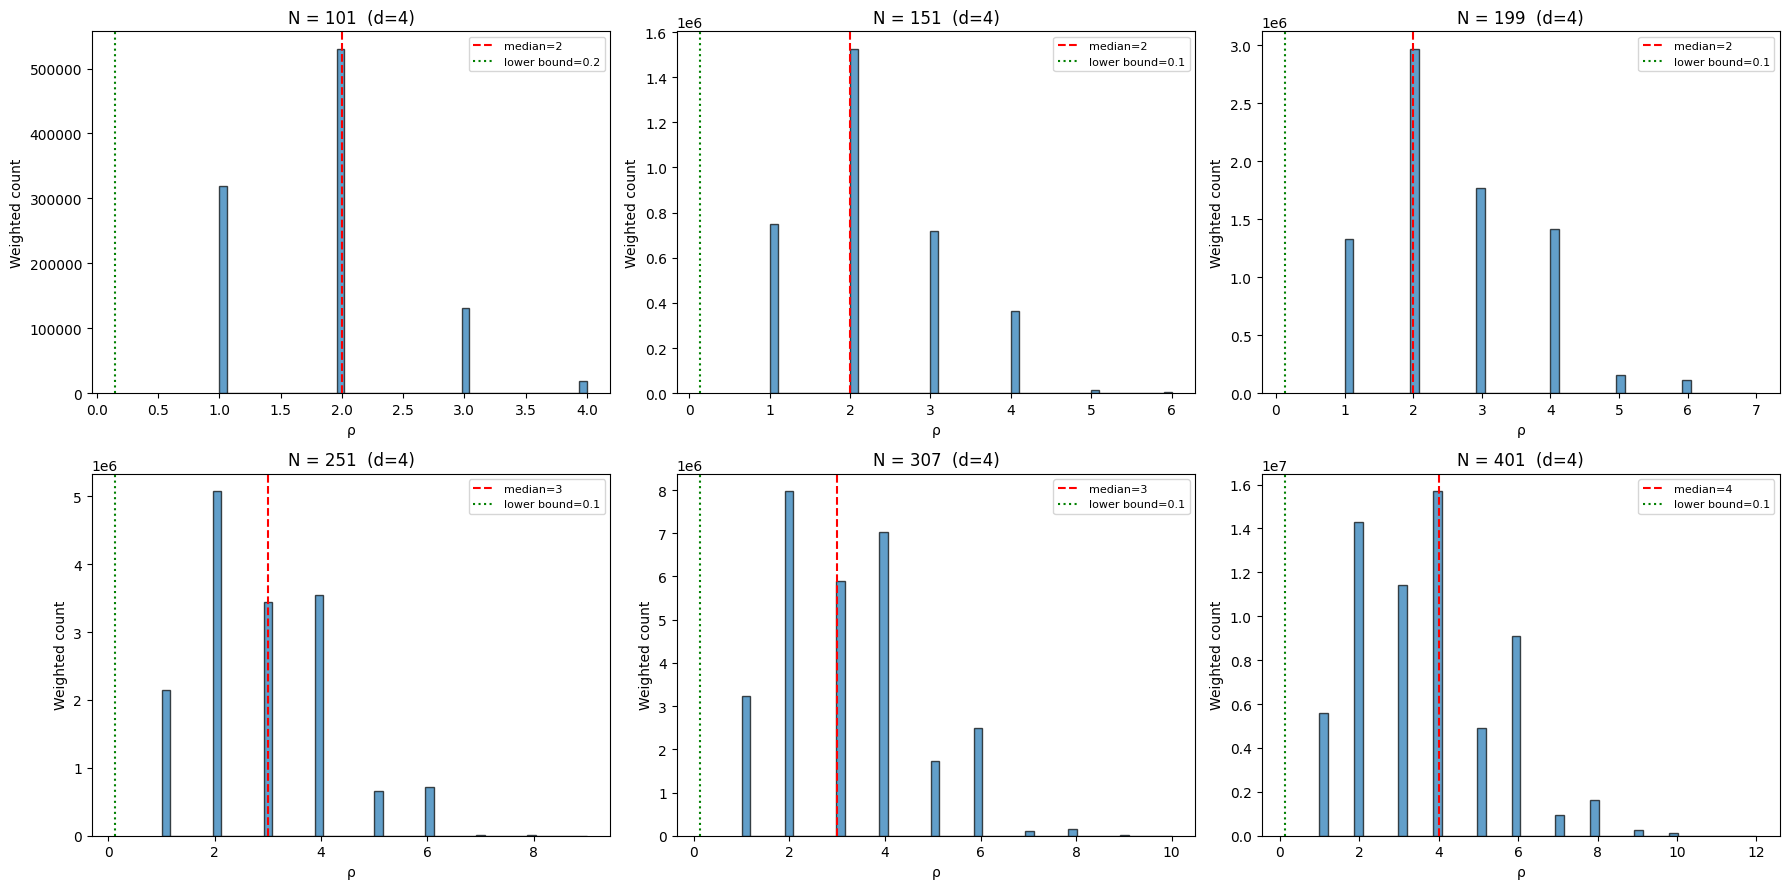

In [ ]:
DELTA = 0.5
C = 1.0

def psi(N):
    return math.log(N) * (math.log(math.log(N)))**(1 + DELTA)

def rho_lower_bound(N, d):
    return C * N / psi(N)**(d - 1)

ncols = 3
nrows = (len(N_values_4d) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4.5 * nrows))
axes = axes.flatten()

for i, N in enumerate(N_values_4d):
    ax = axes[i]
    data = results_4d[N]
    rho_arr = data['rho_values']
    w_arr = data['weights']
    stats = data['stats']
    lb = rho_lower_bound(N, 4)
    
    ax.hist(rho_arr, bins=50, weights=w_arr, edgecolor='black', alpha=0.7)
    ax.axvline(stats['median'], color='red', linestyle='--', linewidth=1.5, label=f"median={stats['median']}")
    ax.axvline(lb, color='green', linestyle=':', linewidth=1.5, label=f"lower bound={lb:.1f}")
    ax.set_title(f"N = {N}  (d=4)")
    ax.set_xlabel("ρ")
    ax.set_ylabel("Weighted count")
    ax.legend(fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


Now we try for a more efficeint version for calculation, this version 

In [13]:
# ============================================================
# Fast LLL-based Zaremba computation (pure Python LLL, no sympy)
# ============================================================

# Precompute all 7^4 - 1 = 2400 nonzero coefficient vectors for the local search
_COEFFS_4D = np.array(
    [(c1, c2, c3, c4)
     for c1 in range(-3, 4) for c2 in range(-3, 4)
     for c3 in range(-3, 4) for c4 in range(-3, 4)
     if not (c1 == 0 and c2 == 0 and c3 == 0 and c4 == 0)],
    dtype=np.int64
)  # shape (2400, 4)


def _lll_4d(N, g2, g3, g4):
    """
    Pure-Python LLL reduction for the 4×4 dual lattice basis
    [[N,0,0,0],[-g2,1,0,0],[-g3,0,1,0],[-g4,0,0,1]].
    Returns reduced basis as list of 4 lists.
    """
    B = [[N, 0, 0, 0], [-g2, 1, 0, 0], [-g3, 0, 1, 0], [-g4, 0, 0, 1]]

    def gs():
        Bs = [None, None, None, None]
        mu = [[0.0, 0.0, 0.0, 0.0] for _ in range(4)]
        Bn = [0.0, 0.0, 0.0, 0.0]
        for i in range(4):
            bi = B[i]
            s0, s1, s2, s3 = float(bi[0]), float(bi[1]), float(bi[2]), float(bi[3])
            for j in range(i):
                if Bn[j] > 0:
                    bj = Bs[j]
                    m = (bi[0]*bj[0] + bi[1]*bj[1] + bi[2]*bj[2] + bi[3]*bj[3]) / Bn[j]
                    mu[i][j] = m
                    s0 -= m * bj[0]; s1 -= m * bj[1]
                    s2 -= m * bj[2]; s3 -= m * bj[3]
            Bs[i] = (s0, s1, s2, s3)
            Bn[i] = s0*s0 + s1*s1 + s2*s2 + s3*s3
        return mu, Bn

    k = 1
    mu, Bn = gs()
    while k < 4:
        for j in range(k - 1, -1, -1):
            if abs(mu[k][j]) > 0.5:
                r = round(mu[k][j])
                bk = B[k]; bj = B[j]
                bk[0] -= r*bj[0]; bk[1] -= r*bj[1]
                bk[2] -= r*bj[2]; bk[3] -= r*bj[3]
                mu, Bn = gs()
        if Bn[k] >= (0.75 - mu[k][k-1]**2) * Bn[k-1]:
            k += 1
        else:
            B[k], B[k-1] = B[k-1], B[k]
            mu, Bn = gs()
            k = max(k - 1, 1)
    return B


def fast_zaremba_lll(N, alpha, search_radius=3):
    """
    Computes the 4D Zaremba index using LLL reduction + vectorized local search.
    Returns (rho, best_h).
    """
    g2 = round(alpha[0] * N)
    g3 = round(alpha[1] * N)
    g4 = round(alpha[2] * N)
    basis = _lll_4d(N, g2, g3, g4)
    basis_np = np.array(basis, dtype=np.int64)
    H = _COEFFS_4D @ basis_np                          # (2400, 4)
    rhos = np.prod(np.maximum(np.abs(H), 1), axis=1)   # product norm
    idx = int(np.argmin(rhos))
    return int(rhos[idx]), tuple(int(x) for x in H[idx])


def fast_zaremba_lll_integer(N, g_vec):
    """
    Computes the 4D Zaremba index using LLL reduction + vectorized local search.
    Accepts integer g-vector (1, g2, g3, g4). Returns rho only.
    """
    basis = _lll_4d(N, g_vec[1], g_vec[2], g_vec[3])
    basis_np = np.array(basis, dtype=np.int64)
    H = _COEFFS_4D @ basis_np
    rhos = np.prod(np.maximum(np.abs(H), 1), axis=1)
    return int(rhos.min())


def analyze_rho_distribution_4d_lll(N_values):
    """
    For each N, compute rho for all symmetry-reduced 4D g-vectors
    using LLL lattice reduction.
    """
    results = {}
    for N in N_values:
        print(f"N = {N} ...", end=" ", flush=True)
        t0 = time.time()
        rho_vals = []
        weights = []

        for g_vec, w in generate_optimized_g_vectors_4d(N):
            rho = fast_zaremba_lll_integer(N, g_vec)
            rho_vals.append(rho)
            weights.append(w)

        rho_arr = np.array(rho_vals)
        w_arr = np.array(weights)

        sorted_idx = np.argsort(rho_arr)
        rho_sorted = rho_arr[sorted_idx]
        w_sorted = w_arr[sorted_idx]
        cum_w = np.cumsum(w_sorted)
        total_w = cum_w[-1]

        def weighted_quantile(q):
            idx = np.searchsorted(cum_w, q * total_w)
            idx = min(idx, len(rho_sorted) - 1)
            return rho_sorted[idx]

        stats = {
            'min': int(rho_sorted[0]),
            'Q1': int(weighted_quantile(0.25)),
            'median': int(weighted_quantile(0.50)),
            'Q3': int(weighted_quantile(0.75)),
            'max': int(rho_sorted[-1]),
            'n_vectors': len(rho_vals),
            'total_weight': int(total_w),
        }

        elapsed = time.time() - t0
        print(f"done in {elapsed:.1f}s  (vectors: {stats['n_vectors']}, "
              f"min={stats['min']}, median={stats['median']}, max={stats['max']})")

        results[N] = {
            'rho_values': rho_arr,
            'weights': w_arr,
            'stats': stats,
        }
    return results

Now lets run it for bigger values

--- Stats for N=1009 ---
Total valid vectors: 171207120
Min: 0, Median: 6, Max: 26


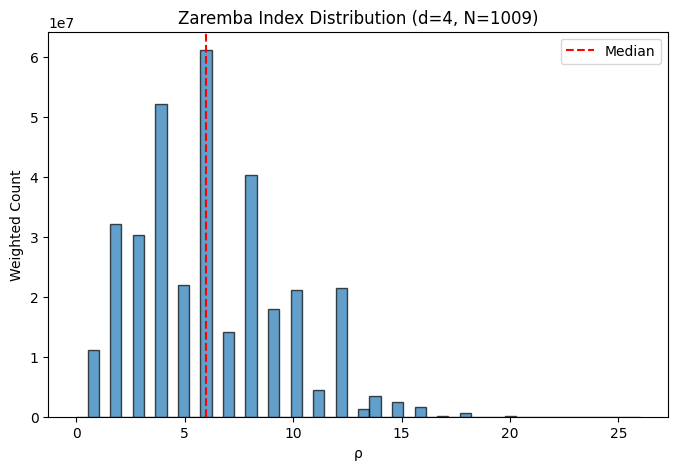

In [ ]:
def analyze_and_plot_saved_data(N):
    # Load the precomputed data
    data = np.load(f"zaremba_4d_N{N}.npz")
    rhos = data['rhos']
    weights = data['weights']
    
    # Calculate weighted statistics instantly
    sorted_idx = np.argsort(rhos)
    rho_sorted = rhos[sorted_idx]
    w_sorted = weights[sorted_idx]
    cum_w = np.cumsum(w_sorted)
    total_w = cum_w[-1]
    
    def weighted_quantile(q):
        idx = np.searchsorted(cum_w, q * total_w)
        idx = min(idx, len(rho_sorted) - 1)
        return rho_sorted[idx]
        
    print(f"--- Stats for N={N} ---")
    print(f"Total valid vectors: {len(rhos)}")
    print(f"Min: {rho_sorted[0]}, Median: {weighted_quantile(0.50)}, Max: {rho_sorted[-1]}")
    
    # Plotting
    plt.figure(figsize=(8, 5))
    plt.hist(rhos, bins=50, weights=weights, edgecolor='black', alpha=0.7)
    plt.axvline(weighted_quantile(0.50), color='red', linestyle='--', label='Median')
    plt.title(f"Zaremba Index Distribution (d=4, N={N})")
    plt.xlabel("ρ")
    plt.ylabel("Weighted Count")
    plt.legend()
    plt.show()

Starting N=401...
Finished N=401 in 3.7s. Saved to zaremba_4d_N401.npz
Starting N=503...
Finished N=503 in 5.6s. Saved to zaremba_4d_N503.npz
Starting N=1009...
Finished N=1009 in 79.4s. Saved to zaremba_4d_N1009.npz
Starting N=1511...
Finished N=1511 in 377.6s. Saved to zaremba_4d_N1511.npz
Starting N=2003...
Finished N=2003 in 1282.2s. Saved to zaremba_4d_N2003.npz

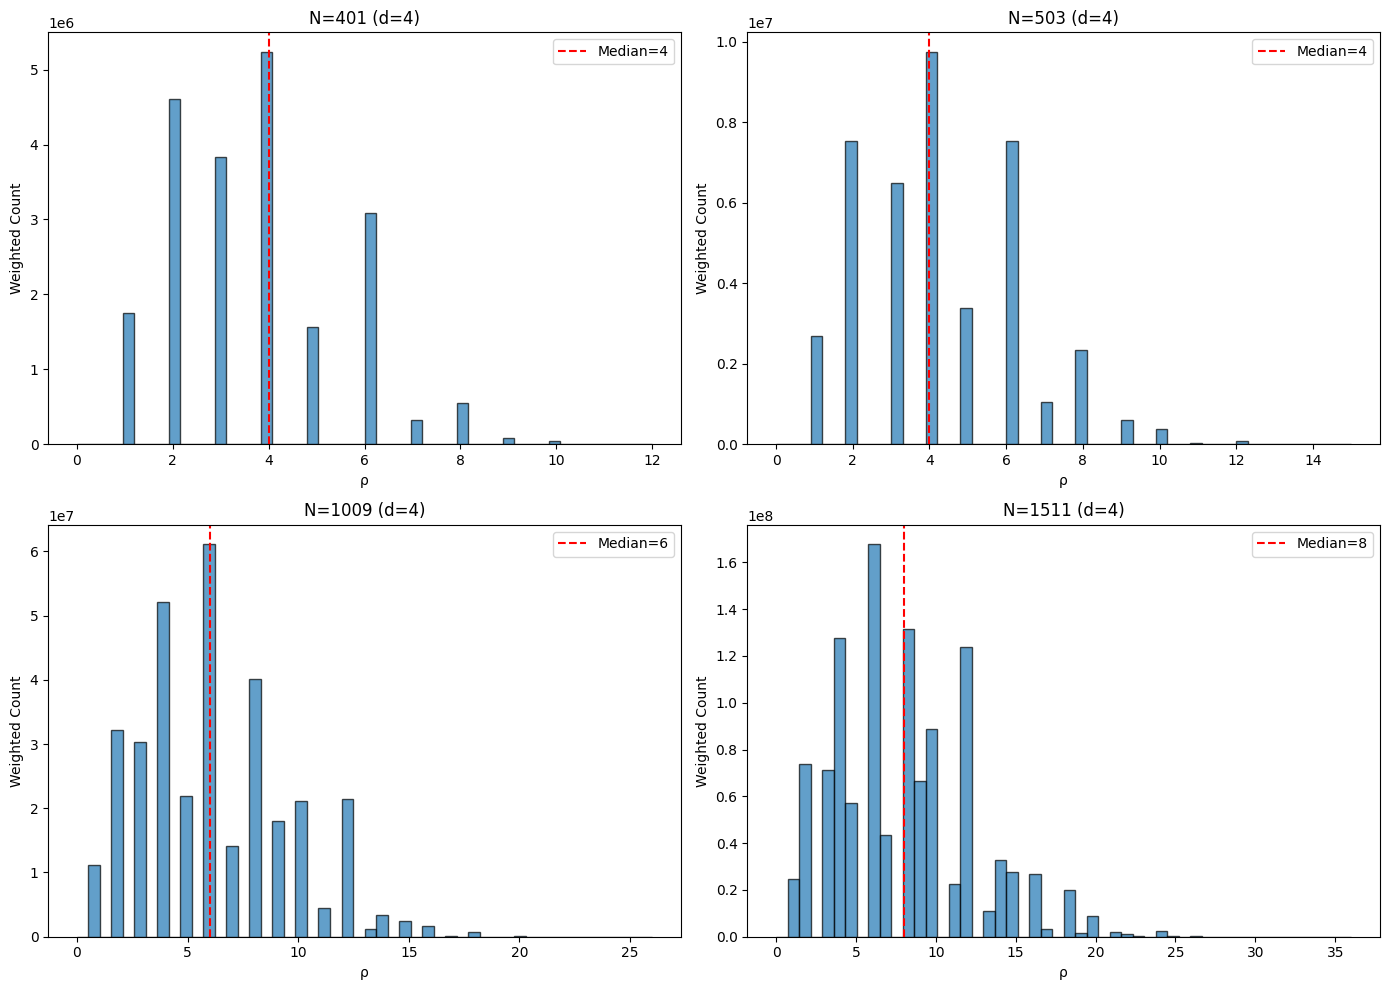

In [21]:
def plot_4_histograms(N_list):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()

    for i, N in enumerate(N_list):
        ax = axes[i]
        data = np.load(f"zaremba_4d_N{N}.npz")
        rhos = data['rhos']
        weights = data['weights']

        sorted_idx = np.argsort(rhos)
        rho_sorted = rhos[sorted_idx]
        w_sorted = weights[sorted_idx]
        cum_w = np.cumsum(w_sorted)
        total_w = cum_w[-1]
        median_idx = np.searchsorted(cum_w, 0.5 * total_w)
        median_idx = min(median_idx, len(rho_sorted) - 1)
        median_val = rho_sorted[median_idx]

        ax.hist(rhos, bins=50, weights=weights, edgecolor='black', alpha=0.7)
        ax.axvline(median_val, color='red', linestyle='--', label=f'Median={median_val}')
        ax.set_title(f"N={N} (d=4)")
        ax.set_xlabel("ρ")
        ax.set_ylabel("Weighted Count")
        ax.legend()

    plt.tight_layout()
    plt.show()

plot_4_histograms([401, 503, 1009, 1511])


--- Stats for N=2003 ---
Total valid vectors: 1339342004
Min: 0, Median: 8, Max: 45


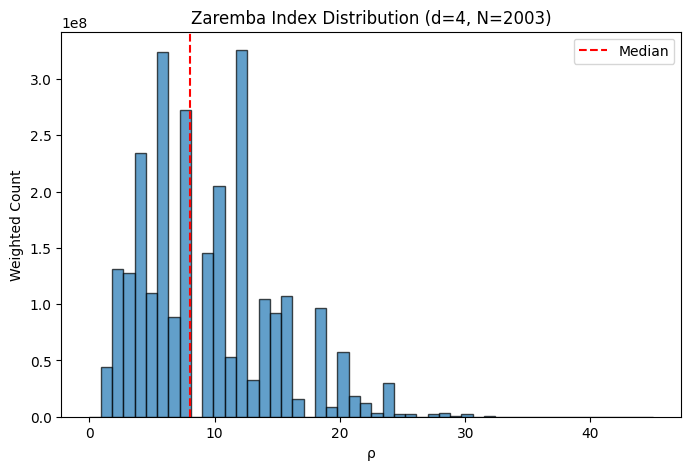

In [23]:
analyze_and_plot_saved_data(2003)